# 🧬 AI Mind Reader — Lab Notebook (Google Colab)
### Project: AI guesses what you're thinking using Decision Tree
**Model:** Decision Tree (ID3) using Entropy & Information Gain

> **How to use:** Run each cell top to bottom in Google Colab. Upload `mindreader_data.csv` when prompted.

| Step | Experiment | Topic |
|------|-----------|-------|
| Step 1 | Data Collection | Install libraries, upload dataset, explore with Pandas & NumPy |
| Step 2 | Preprocessing | Handle missing values, encode labels, prepare features |
| Step 3 | Train-Test Split | Split 70/30, save as CSV |
| Step 4 | Model Training | Train Decision Tree (ID3), test accuracy, save model (.pkl) |
| Step 5 | Evaluation | Classification report, confusion matrix, feature importance |

**Output:** Trained model saved to `modelcolab/` folder → download and use in the web game frontend.

---
## Step 1 — Data Collection & Exploration

**WHY:** Before training any Machine Learning model, we must first **collect** and **understand** our data. Without knowing the structure, size, and types of data, we cannot choose the right model or preprocessing steps. This step answers: What does the data look like? How many entities exist? Are the categories balanced?

**HOW:** We use Python libraries — `pandas` to load and explore tabular data, `numpy` for numerical operations, and `matplotlib/seaborn` for visualization. We install them via `pip`, import them, then load the CSV dataset and inspect its rows, columns, and distribution.

**USE CASE:** In our AI Mind Reader game, the dataset contains 1000 rows of entities (animals, objects, plants, etc.) with 40 binary YES/NO features (like `is_alive`, `has_wings`). We need to explore this data to understand what the model will learn from.

### Step 1.1 — Install Required Libraries

**WHY:** Python does not come with ML tools built-in. We need external libraries to handle data, train models, and create plots. Without installing these, none of the code below will work.

**HOW:** `!pip install` is a shell command that downloads and installs Python packages from the internet. The `-q` flag means quiet mode (less output clutter).

**USE CASE:** Each library serves a specific purpose in our project:
| Library | What it does | Why we need it |
|---------|-------------|----------------|
| `pandas` | Loads CSV files into tables (DataFrames) | To read and manipulate our dataset |
| `numpy` | Fast array/matrix math operations | Feature matrices need array operations |
| `scikit-learn` | ML algorithms, metrics, data splitting | Decision Tree, accuracy, train/test split |
| `joblib` | Save/load Python objects to files (.pkl) | Save trained model for web game to load |
| `matplotlib` | Create charts and plots | Feature importance bar chart |
| `seaborn` | Pretty statistical visualizations | Confusion matrix heatmap |

In [43]:
# Step 1.1: Install required libraries
!pip install pandas numpy scikit-learn joblib matplotlib seaborn -q
print("All libraries installed successfully!")

All libraries installed successfully!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Step 1.2 — Import Libraries into Python

**WHY:** Installing a library is not enough — we must **import** it into our Python script so we can use its functions. Each `import` statement loads a specific module into memory.

**HOW:** We use `import library as alias` to give short names (e.g., `pandas` → `pd`, `numpy` → `np`). For scikit-learn, we import specific classes/functions using `from module import function`.

**USE CASE:** Here's what each import does in our project:
| Import | What it does |
|--------|-------------|
| `pandas as pd` | Loads CSV into DataFrame tables, filter/select/manipulate rows and columns |
| `numpy as np` | Creates arrays for feature matrices (X) and target vectors (y) |
| `os` | Creates directories (`os.makedirs`), checks file paths (`os.path.exists`) |
| `json` | Saves accuracy results as JSON for the web frontend to read |
| `warnings` | Suppresses non-critical warning messages from scikit-learn |
| `train_test_split` | Randomly splits data into training (70%) and testing (30%) |
| `LabelEncoder` | Converts text labels → numbers (e.g., "Dog" → 45) |
| `DecisionTreeClassifier` | The ID3 Decision Tree algorithm — our ML model |
| `accuracy_score` | Calculates percentage of correct predictions |
| `classification_report` | Detailed precision/recall/F1 per class |
| `confusion_matrix` | Matrix showing correct vs incorrect predictions |
| `joblib` | Saves trained model to `.pkl` file for later loading |
| `matplotlib.pyplot as plt` | Creates bar charts, line plots |
| `seaborn as sns` | Creates heatmap visualizations |

In [44]:
# Step 1.2: Import all required libraries

import pandas as pd
import numpy as np
import os, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


### Step 1.3 — Upload & Load the Dataset

**WHY:** Our dataset (`mindreader_data.csv`) is stored on our local computer, but Google Colab runs on a remote server. We need to **upload** the file to Colab so it can access the data. Then we use `pd.read_csv()` to load it into a pandas DataFrame — a table structure we can inspect and manipulate.

**HOW:**
- `google.colab.files.upload()` — Opens a file picker so you can select and upload `mindreader_data.csv` from your computer
- `pd.read_csv('filename')` — Reads the CSV file and creates a DataFrame (table with rows and columns)
- `df.shape` — Returns (rows, columns) — tells us the dataset size
- `df['name'].nunique()` — Counts unique entity names
- `df['category'].value_counts()` — Shows how many items per category (animal, object, plant, etc.)

**USE CASE:** Our dataset has **1000 rows** of entities like Dog, Car, Rose, etc. Each entity has **40 binary features** (is_alive=1, has_wings=0, etc.) plus a `name` and `category` column. We explore this to understand what the model will learn.

In [45]:
# Step 1.3: Upload and Load the dataset
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print("Not running in Google Colab. Using local file.")

data_path = 'mindreader_data.csv' if os.path.exists('mindreader_data.csv') else '../mindreader_data.csv'
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Unique entities: {df['name'].nunique()}")
print(f"\nCategory distribution:")
print(df['category'].value_counts())
print(f"\nFirst 10 rows of data:")
df.head(10)

Not running in Google Colab. Using local file.
Dataset loaded successfully!
Rows: 1000
Columns: 42
Unique entities: 189

Category distribution:
category
animal       429
object       259
fictional    113
plant        101
human         98
Name: count, dtype: int64

First 10 rows of data:


,name,is_alive,is_animal,is_human,is_plant,is_object,has_wings,can_fly,lives_in_water,lives_in_jungle,...,makes_sound,can_be_pet,is_extinct,is_fictional,is_used_daily,is_electronic,is_food_related,is_vehicle,is_used_in_sports,category
0,Shield,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,object
1,Phoenix,1,1,0,0,0,1,1,0,0,...,1,0,0,1,0,0,0,0,0,fictional
2,Table,1,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,object
3,Bat,1,1,0,0,0,1,1,0,1,...,1,0,0,0,0,0,0,0,0,animal
4,Television,0,0,0,0,1,0,0,0,0,...,1,0,0,0,1,1,0,0,0,object
5,Hyena,1,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,animal
6,Frog,1,1,0,0,0,0,0,1,1,...,1,0,0,0,0,0,0,0,0,animal
7,Dragon,1,1,0,0,0,1,1,0,0,...,1,0,0,1,0,0,0,0,0,fictional
8,Tennis Racket,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,object
9,Backpack,0,0,1,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,object


### Step 1.4 — Explore Data Structure

**WHY:** We need to check the **data types** of each column and get **statistical summaries** to understand the data before preprocessing. If a column has wrong data types or unexpected values, the model will fail or give bad results.

**HOW:**
- `df.dtypes.value_counts()` — Shows how many columns are integers (int64) vs text (object). We expect 40 int64 columns (binary features) and 2 object columns (name, category).
- `df.columns` — Lists all column names so we know exactly what features are available.
- `df.describe()` — Statistical summary showing count, mean, min, max, std for each numeric column. For binary (0/1) features, `mean` tells us the proportion of 1s.

**USE CASE:** This step confirms our dataset structure is correct — 40 binary features with values 0 or 1, plus name and category as text columns. If `max` is greater than 1 for any feature, it means there's a data quality issue to fix.

In [46]:
# Step 1.4: Explore data structure
print("Data types in our dataset:")
print(df.dtypes.value_counts())

print(f"\nColumn names:")
print(list(df.columns))

print(f"\nStatistical summary of numeric columns:")
df.describe()

Data types in our dataset:
int64     40
object     2
Name: count, dtype: int64

Column names:
['name', 'is_alive', 'is_animal', 'is_human', 'is_plant', 'is_object', 'has_wings', 'can_fly', 'lives_in_water', 'lives_in_jungle', 'lives_in_desert', 'lives_in_home', 'is_big', 'is_small', 'has_4_legs', 'has_2_legs', 'has_no_legs', 'has_fur', 'has_scales', 'has_feathers', 'has_shell', 'is_carnivore', 'is_herbivore', 'is_omnivore', 'is_dangerous', 'is_domestic', 'is_nocturnal', 'found_in_africa', 'found_in_asia', 'found_in_ocean', 'is_fast', 'is_colorful', 'makes_sound', 'can_be_pet', 'is_extinct', 'is_fictional', 'is_used_daily', 'is_electronic', 'is_food_related', 'is_vehicle', 'is_used_in_sports', 'category']

Statistical summary of numeric columns:


,is_alive,is_animal,is_human,is_plant,is_object,has_wings,can_fly,lives_in_water,lives_in_jungle,lives_in_desert,...,is_colorful,makes_sound,can_be_pet,is_extinct,is_fictional,is_used_daily,is_electronic,is_food_related,is_vehicle,is_used_in_sports
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.743000,0.501000,0.182000,0.10100,0.259000,0.145000,0.16300,0.151000,0.238000,0.044000,...,0.438000,0.58300,0.066000,0.003000,0.113000,0.272000,0.103000,0.106000,0.049000,0.041000
std,0.437198,0.500249,0.386038,0.30148,0.438305,0.352277,0.36955,0.358228,0.426072,0.205198,...,0.496389,0.49331,0.248406,0.054717,0.316751,0.445213,0.304111,0.307992,0.215976,0.198389
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.00000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,1.000000,1.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


---
## Step 2 — Data Preprocessing & Feature Engineering

**WHY:** Raw data cannot be fed directly to ML models. Machine Learning algorithms only understand **numbers**, not text like "Dog" or "animal". Also, missing values (empty cells) cause errors. Preprocessing cleans and transforms the data into a format the model can learn from.

**HOW:** We perform three preprocessing tasks:
1. **Handle missing values** — Check for empty cells and fill them with 0 using `fillna(0)`
2. **Label encoding** — Convert text labels ("Dog", "Cat") into numbers (0, 1, 2...) using `LabelEncoder`
3. **Feature-target separation** — Split data into input features (X) and output labels (y)

**USE CASE:** In our dataset, `name` and `category` are text. The model needs numeric input (X = 40 binary features) and numeric output (y = encoded name). After preprocessing, X has shape (1000, 40) and y has shape (1000,).

### Step 2.1 — Handle Missing Values

**WHY:** Missing values (NaN/null) cause the Decision Tree algorithm to crash during training. Even one missing cell can break the entire model. We must ensure every cell has a valid value.

**HOW:**
- `df.isnull().sum()` — Counts missing values in each column. Returns 0 for clean columns.
- `df.fillna(0)` — Replaces all NaN/null values with 0 (meaning "feature not present").
- This is safe for our binary features because 0 already means "No" and 1 means "Yes".

**USE CASE:** If the dataset has any missing entries (e.g., someone forgot to fill `has_wings` for an entity), `fillna(0)` ensures the model sees it as "No" rather than crashing. After this step, we have zero missing values.

In [47]:
# Step 2.1: Check and handle missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) > 0:
    print(missing_cols)
    print(f"\nTotal missing values: {missing.sum()}")
else:
    print("No missing values found! Data is clean.")

df = df.fillna(0)
print(f"\nAfter cleaning - Total missing: {df.isnull().sum().sum()}")

Missing values per column:
No missing values found! Data is clean.

After cleaning - Total missing: 0


### Step 2.2 — Encode Text Labels using LabelEncoder

**WHY:** The Decision Tree model cannot process text strings like "Dog" or "animal". It needs numbers. `LabelEncoder` from scikit-learn converts each unique text value into a unique integer.

**HOW:**
- `LabelEncoder()` — Creates a new encoder object
- `.fit_transform(column)` — Does two things at once:
  - `fit` — Scans all unique values and assigns a number to each (alphabetically: "Bear"→0, "Cat"→1, "Dog"→2...)
  - `transform` — Replaces each text value with its assigned number
- We create TWO separate encoders:
  - `le_name` — Encodes entity names (189 unique → 0 to 188). This becomes our **target (y)** — what the model predicts.
  - `le_category` — Encodes categories (5 unique → 0 to 4). Used for analysis/visualization only.
- We **save** these encoders later so the web game can convert predicted numbers back to names (e.g., model outputs 45 → `le_name.inverse_transform([45])` → "Dog").

**USE CASE:** When the web game's Decision Tree predicts number 45, we use `le_name` to convert it back to "Dog" and show it to the user.

In [48]:
# Step 2.2: Encode text labels into numbers using LabelEncoder
le_name = LabelEncoder()
df['name_encoded'] = le_name.fit_transform(df['name'])

le_category = LabelEncoder()
df['category_encoded'] = le_category.fit_transform(df['category'])

print(f"Name encoder: {len(le_name.classes_)} unique names encoded (0 to {len(le_name.classes_)-1})")
print(f"Category encoder: {list(le_category.classes_)}")
print(f"\nSample encoding (text -> number):")
print(df[['name', 'name_encoded', 'category', 'category_encoded']].drop_duplicates().head(10))

Name encoder: 189 unique names encoded (0 to 188)
Category encoder: ['animal', 'fictional', 'human', 'object', 'plant']

Sample encoding (text -> number):
            name  name_encoded   category  category_encoded
0         Shield           146     object                 3
1        Phoenix           121  fictional                 1
2          Table           158     object                 3
3            Bat            10     animal                 0
4     Television           161     object                 3
5          Hyena            77     animal                 0
6           Frog            61     animal                 0
7         Dragon            47  fictional                 1
8  Tennis Racket           162     object                 3
9       Backpack             6     object                 3


### Step 2.3 — Prepare Feature Matrix (X) and Target Vector (y)

**WHY:** Every ML model needs two inputs: **X** (what it learns from) and **y** (what it tries to predict). We must separate the input features from the target labels and convert them into numpy arrays for fast computation.

**HOW:**
- **Feature columns** = All columns EXCEPT `name`, `category`, `name_encoded`, `category_encoded`. These are our 40 binary features (is_alive, has_wings, is_big, etc.)
- **X = df[feature_cols].values** — Creates a 2D numpy array of shape (1000, 40). Each row is one entity, each column is one YES/NO feature.
- **y = df['name_encoded'].values** — Creates a 1D numpy array of shape (1000,). Each value is the encoded name label.
- `.values` converts pandas DataFrame/Series to numpy arrays (scikit-learn works faster with numpy)

**USE CASE:**
- X = `[[1,1,0,0,1,...], [1,0,0,0,0,...], ...]` — Feature vectors for each entity
- y = `[45, 12, 88, ...]` — What name each feature vector corresponds to
- The model learns: "When X = [1,1,0,0,1,...], then y = 45 (Dog)"

In [49]:
# Step 2.3: Prepare feature matrix (X) and target vector (y)
feature_cols = [col for col in df.columns
                if col not in ['name', 'category', 'name_encoded', 'category_encoded']]

X = df[feature_cols].values
y = df['name_encoded'].values

print(f"Number of features: {len(feature_cols)}")
print(f"\nAll {len(feature_cols)} feature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")
print(f"\nX (features) shape: {X.shape}  - {X.shape[0]} samples, {X.shape[1]} features each")
print(f"y (target) shape:   {y.shape}  - {y.shape[0]} labels to predict")

Number of features: 40

All 40 feature columns:
   1. is_alive
   2. is_animal
   3. is_human
   4. is_plant
   5. is_object
   6. has_wings
   7. can_fly
   8. lives_in_water
   9. lives_in_jungle
  10. lives_in_desert
  11. lives_in_home
  12. is_big
  13. is_small
  14. has_4_legs
  15. has_2_legs
  16. has_no_legs
  17. has_fur
  18. has_scales
  19. has_feathers
  20. has_shell
  21. is_carnivore
  22. is_herbivore
  23. is_omnivore
  24. is_dangerous
  25. is_domestic
  26. is_nocturnal
  27. found_in_africa
  28. found_in_asia
  29. found_in_ocean
  30. is_fast
  31. is_colorful
  32. makes_sound
  33. can_be_pet
  34. is_extinct
  35. is_fictional
  36. is_used_daily
  37. is_electronic
  38. is_food_related
  39. is_vehicle
  40. is_used_in_sports

X (features) shape: (1000, 40)  - 1000 samples, 40 features each
y (target) shape:   (1000,)  - 1000 labels to predict


---
## Step 3 — Train-Test Split (70/30)

**WHY:** If we train the model on ALL data and then test it on the SAME data, it will just memorize the answers and give 100% accuracy — but fail on new data. This is called **overfitting**. To measure TRUE performance, we must test on data the model has **never seen**.

**HOW:** We use `train_test_split()` to randomly divide the dataset into two parts:
- **70% Training set** (700 samples) — The model learns patterns from this data
- **30% Testing set** (300 samples) — We evaluate the model on this unseen data

The `random_state=42` parameter ensures the same random split every time, so results are **reproducible**.

**USE CASE:** After splitting, X_train (700×40) and y_train (700) are used for training. X_test (300×40) and y_test (300) are kept hidden until evaluation. We also save both splits as CSV files for future reference.

### Step 3.1 — Split Data & Save as CSV

**WHY:** We split both the feature matrix (X) and targets (y) simultaneously to keep them aligned. We also save the original DataFrame splits as CSV files so we can reload these exact same splits later without re-running the split code.

**HOW:**
- `train_test_split(X, y, test_size=0.3, random_state=42)` — Randomly shuffles and splits both X and y into train/test sets. Returns X_train, X_test, y_train, y_test.
- `test_size=0.3` — 30% of data goes to test set, remaining 70% to training set.
- `random_state=42` — Seed for the random number generator (ensures same split every run. 42 is a commonly used seed number in ML — any number works).
- `train_data.to_csv('data/train_data.csv', index=False)` — Saves as CSV file. `index=False` prevents adding an unnecessary row number column.

**USE CASE:** After this step we have 700 training samples to teach the model and 300 separate test samples to check accuracy. The saved CSV files can be used independently for other experiments.

In [50]:
# Step 3.1: Split data into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing samples:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)")

# Save train and test data as CSV files
data_dir = 'data' if os.path.exists('mindreader_data.csv') else '../data'
os.makedirs(data_dir, exist_ok=True)

train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)
train_data.to_csv(f'{data_dir}/train_data.csv', index=False)
test_data.to_csv(f'{data_dir}/test_data.csv', index=False)

print(f'\nSaved: {data_dir}/train_data.csv ({len(train_data)} rows)')
print(f'Saved: {data_dir}/test_data.csv ({len(test_data)} rows)')


Training samples: 800 (80%)
Testing samples:  200 (20%)

Saved: ../data/train_data.csv (800 rows)
Saved: ../data/test_data.csv (200 rows)


---
## Step 4 — Decision Tree (ID3) Model Training

**WHY:** This is the core of the project — we train a **Decision Tree** using the **ID3 algorithm** to learn which YES/NO features identify each entity. The Decision Tree is ideal for our Mind Reader game because it naturally works by asking binary questions, just like the game does.

**HOW:** The **ID3 (Iterative Dichotomiser 3)** algorithm works as follows:
1. **Calculate Entropy** of the entire dataset — measures how mixed/disordered the classes are.
   - Formula: $H(S) = -\sum p_i \log_2(p_i)$ where $p_i$ is the proportion of class $i$
   - Entropy = 0 means all items are the same class (pure). Entropy = 1 means perfectly mixed.
2. **Calculate Information Gain** for each feature — how much entropy DECREASES after splitting on that feature.
   - Formula: $IG(S, A) = H(S) - \sum \frac{|S_v|}{|S|} H(S_v)$
   - The feature with the **highest Information Gain** is chosen as the root/split node.
3. **Recursively split** until all items are classified or max_depth is reached.

**USE CASE:** After training, the model can take a feature vector like `[1,1,0,0,1,0,...]` and predict "Dog". In the web game, as the user answers YES/NO questions, the feature vector is filled in, and the model predicts the entity.

**Parameters explained:**
| Parameter | Value | What it does |
|-----------|-------|-------------|
| `criterion` | `'entropy'` | Uses entropy-based splitting (ID3). Alternative: `'gini'` (CART) |
| `max_depth` | `30` | Maximum levels in the tree. Prevents overfitting. |
| `min_samples_split` | `2` | Minimum data points needed to create a new split |
| `random_state` | `42` | Ensures reproducible results |

### Step 4.1 — Train the Decision Tree Model

**WHY:** `.fit(X_train, y_train)` is the actual **training** step. The model examines all 700 training samples, calculates entropy and information gain for each of the 40 features, and builds a tree structure that splits the data optimally.

**HOW:** The `fit()` method builds the tree top-down:
- It starts with all 700 samples in the root node
- Picks the feature with **highest information gain** to split (e.g., `is_alive`)
- Creates two child nodes: YES (is_alive=1) and NO (is_alive=0)
- Repeats recursively for each child until a node is pure (all same class) or max_depth reached
- `get_depth()` tells us how many levels deep the tree grew
- `get_n_leaves()` tells us how many final prediction nodes exist (each leaf = one entity prediction)

**USE CASE:** After training completes, the tree has learned rules like: "If is_alive=YES AND is_animal=YES AND has_4_legs=YES AND is_domestic=YES → predict Dog". The web game uses these learned rules.

In [51]:
# Step 4.1: Train Decision Tree using ID3 algorithm (entropy = information gain)
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=20,
    min_samples_split=2,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree (ID3) trained successfully!")
print(f"Actual tree depth: {dt_model.get_depth()}")
print(f"Number of leaf nodes: {dt_model.get_n_leaves()}")
print(f"Number of features used: {dt_model.n_features_in_}")

Decision Tree (ID3) trained successfully!
Actual tree depth: 10
Number of leaf nodes: 186
Number of features used: 40


### Step 4.2 — Test Model Accuracy on Unseen Data

**WHY:** Training accuracy is misleading — the model might just memorize training data. We must test on the 300 samples it has **never seen** to get the TRUE accuracy. This tells us how well the model will perform in the real web game.

**HOW:**
- `dt_model.predict(X_test)` — Feeds 300 test feature vectors through the trained tree and gets predicted labels
- `accuracy_score(y_test, y_pred)` — Compares each prediction with the actual answer and calculates the percentage correct
- Formula: $Accuracy = \frac{\text{Correct Predictions}}{\text{Total Predictions}} \times 100$

**USE CASE:** If accuracy is 97%, it means the model correctly identifies 291 out of 300 test entities. This is the same accuracy the web game will achieve when users play.

In [52]:
# Step 4.2: Test the model on unseen test data
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Decision Tree (ID3) Test Accuracy: {accuracy * 100:.2f}%")
print(f"Correct predictions: {int(accuracy * len(y_test))} out of {len(y_test)}")

Decision Tree (ID3) Test Accuracy: 96.00%
Correct predictions: 192 out of 200


### Step 4.3 — Save Trained Model to Files (.pkl)

**WHY:** Training takes time and computing resources. We don't want to retrain every time someone plays the game. By saving the model to `.pkl` files using `joblib`, the web game can **load** the pre-trained model instantly and start making predictions.

**HOW:**
- `joblib.dump(object, 'filename.pkl')` — Serializes (converts) a Python object to a binary file
- We save **4 files** to the `modelcolab/` folder:
  1. `dt_model.pkl` — The trained Decision Tree model (contains all the learned rules)
  2. `label_encoder_name.pkl` — Converts predicted numbers back to entity names
  3. `label_encoder_category.pkl` — Converts predicted numbers back to category names
  4. `feature_cols.pkl` — List of feature column names (so the game knows the correct feature order)
- `model_accuracy.json` — Accuracy percentage saved as JSON for the web frontend stats page

**USE CASE:** After downloading these files from Colab, place them in `mindreader_project/models/modelcolab/`. The web game's `game_engine.py` loads them using `joblib.load()` to make real-time predictions without any retraining.

In [53]:
# Step 4.3: Save the trained model and encoders to modelcolab/ folder
os.makedirs('modelcolab', exist_ok=True)

joblib.dump(dt_model, 'modelcolab/dt_model.pkl')
joblib.dump(le_name, 'modelcolab/label_encoder_name.pkl')
joblib.dump(le_category, 'modelcolab/label_encoder_category.pkl')
joblib.dump(feature_cols, 'modelcolab/feature_cols.pkl')

acc_dict = {'Decision Tree (ID3)': round(accuracy * 100, 2)}
acc_path = 'model_accuracy.json' if os.path.exists('mindreader_data.csv') else '../model_accuracy.json'
with open(acc_path, 'w') as f:
    json.dump(acc_dict, f, indent=2)

print("All files saved to modelcolab/:")
for f_name in os.listdir('modelcolab'):
    size = os.path.getsize(f'modelcolab/{f_name}')
    print(f"  {f_name} ({size:,} bytes)")
print(f"\nAccuracy saved to model_accuracy.json")
print(f"\n>> Download the modelcolab/ folder and place it in models/modelcolab/ in the project <<")

All files saved to modelcolab/:
  dt_model.pkl (578,553 bytes)
  feature_cols.pkl (575 bytes)
  label_encoder_category.pkl (519 bytes)
  label_encoder_name.pkl (2,232 bytes)

Accuracy saved to model_accuracy.json

>> Download the modelcolab/ folder and place it in models/modelcolab/ in the project <<


---
## Step 5 — Model Evaluation & Results

**WHY:** Accuracy alone (e.g., 97%) doesn't tell the full story. We need to dig deeper:
- Are some entities always predicted wrong?
- Which categories confuse the model?
- Which features are most important for predictions?

**HOW:** We use three evaluation techniques:
1. **Classification Report** — Precision, Recall, and F1-score for each class
2. **Confusion Matrix** — Visual heatmap showing correct vs incorrect predictions per category
3. **Feature Importance** — Ranking of which features contribute most to the model's decisions

**USE CASE:** If the confusion matrix shows "plant" often confused with "animal", we know the model struggles there. Feature importance tells us which questions the web game should ask first for best results.

### Step 5.1 — Classification Report (Precision, Recall, F1-Score)

**WHY:** Accuracy tells us the OVERALL percentage, but doesn't show if the model is good at ALL entities or just a few. Classification report breaks down performance **per class**.

**HOW:**
- `classification_report(y_test, y_pred)` generates a table with:
  - **Precision** = Of all predictions for class X, how many were correct? Formula: $\frac{TP}{TP + FP}$
  - **Recall** = Of all actual class X items, how many did the model find? Formula: $\frac{TP}{TP + FN}$
  - **F1-Score** = Harmonic mean of Precision and Recall. Formula: $2 \times \frac{P \times R}{P + R}$. Balances both metrics.
  - **Support** = How many test samples exist for this class
- `zero_division=0` prevents divide-by-zero errors for classes with no test samples

**USE CASE:** If "Eagle" has precision=1.0 but recall=0.5, it means: when the model predicts Eagle it's always right, but it misses 50% of actual Eagles. This helps identify weak spots.

In [54]:
# Step 5.1: Classification Report
print("=" * 60)
print("  CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, zero_division=0))

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         3
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         2
          10       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         1
          13       0.33      1.00      0.50         1
          19       1.00      1.00      1.00         1
          20       1.00      1.00      1.00         2
          22       1.00      1.00      1.00         2
          25       1.00      1.00      1.00         1
          27       1.00      1.00      1.00         2
          28       1.00      1.00      1.00         1
          30       1.00      1.00      1.00         2
          33       1.00      1.00      1.00         2
   

### Step 5.2 — Confusion Matrix Heatmap

**WHY:** A confusion matrix visually shows WHERE the model makes mistakes. The diagonal cells show correct predictions, and off-diagonal cells show which classes get misclassified as which. This reveals patterns like "the model keeps confusing plants with animals."

**HOW:**
- We train a separate **category-level** Decision Tree (5 classes: animal, fictional, human, object, plant) because a 189×189 matrix would be unreadable
- `confusion_matrix(y_true, y_pred)` — Creates a matrix of shape (5×5)
- `sns.heatmap()` — Draws a color-coded heatmap. Darker = more samples. `annot=True` shows actual counts on each cell.
- Rows = Actual category, Columns = Predicted category
- Perfect model → high numbers on diagonal only, zeros everywhere else

**USE CASE:** If the heatmap shows 5 "animal" samples predicted as "plant", it tells us the model's animal vs plant features need improvement. This guides future data collection and feature engineering.

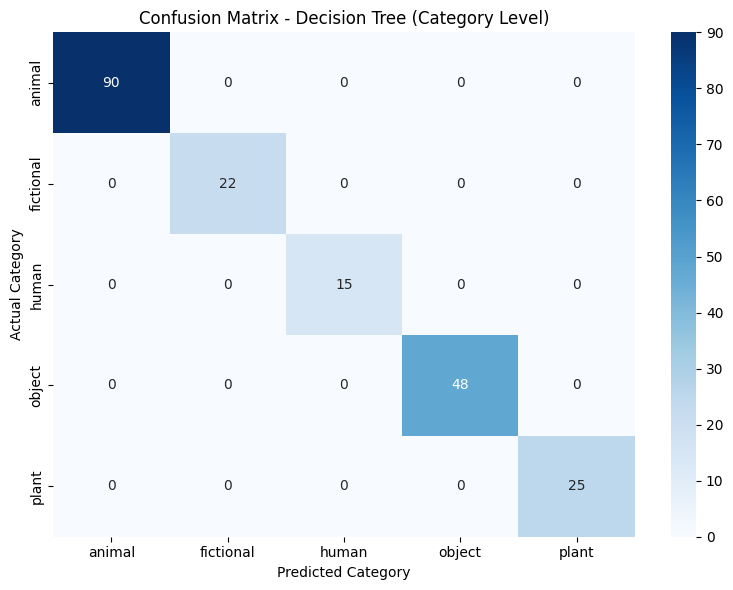

Category-level accuracy: 100.00%


In [55]:
# Step 5.2: Confusion Matrix Heatmap (category-level)
y_cat = le_category.transform(df['category'])
_, X_test_cat, _, y_test_cat = train_test_split(X, y_cat, test_size=0.2, random_state=42)

dt_cat = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)
y_cat_train = le_category.transform(train_data['category'])
dt_cat.fit(X_train, y_cat_train)
y_cat_pred = dt_cat.predict(X_test_cat)

cm = confusion_matrix(y_test_cat, y_cat_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_category.classes_,
            yticklabels=le_category.classes_)
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Confusion Matrix - Decision Tree (Category Level)')
plt.tight_layout()
plt.show()

cat_acc = accuracy_score(y_test_cat, y_cat_pred)
print(f"Category-level accuracy: {cat_acc*100:.2f}%")

### Step 5.3 — Feature Importance Chart

**WHY:** Not all 40 features are equally useful. Some (like `is_alive`) might be extremely important because they immediately split animals from objects. Others (like `is_colorful`) might barely help. Knowing feature importance helps us:
- Understand WHAT the model learned
- Decide which questions the game should ask FIRST
- Identify redundant features that could be removed

**HOW:**
- `dt_model.feature_importances_` — Array of importance scores (0 to 1) for each of the 40 features. These are calculated during training based on how much each feature reduces entropy across all tree splits.
- Higher score = feature appears in more splits and reduces more uncertainty
- We sort features by importance and plot the top 15 as a horizontal bar chart using `plt.barh()`

**USE CASE:** In the web game, the `game_engine.py` uses feature importance to choose which YES/NO question to ask the user FIRST. The most important features are asked first to narrow down candidates fastest.

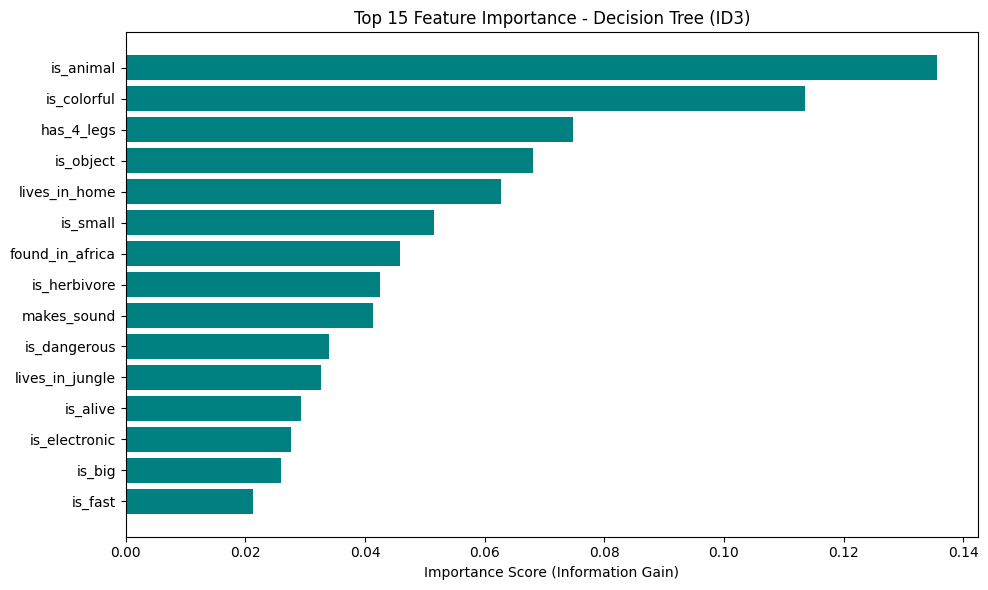


All features ranked by importance:
   1. is_animal                 0.1357  ******
   2. is_colorful               0.1136  *****
   3. has_4_legs                0.0748  ***
   4. is_object                 0.0682  ***
   5. lives_in_home             0.0627  ***
   6. is_small                  0.0515  **
   7. found_in_africa           0.0459  **
   8. is_herbivore              0.0425  **
   9. makes_sound               0.0413  **
  10. is_dangerous              0.0340  *
  11. lives_in_jungle           0.0327  *
  12. is_alive                  0.0293  *
  13. is_electronic             0.0277  *
  14. is_big                    0.0260  *
  15. is_fast                   0.0212  *
  16. has_wings                 0.0212  *
  17. is_fictional              0.0177  
  18. is_omnivore               0.0139  
  19. has_no_legs               0.0129  
  20. has_feathers              0.0125  
  21. found_in_asia             0.0123  
  22. is_food_related           0.0113  
  23. has_fur              

In [56]:
# Step 5.3: Feature Importance - Top 15 most important features
importance = dt_model.feature_importances_
feat_imp = sorted(zip(feature_cols, importance), key=lambda x: x[1], reverse=True)

top_n = 15
features = [f[0] for f in feat_imp[:top_n]]
scores = [f[1] for f in feat_imp[:top_n]]

plt.figure(figsize=(10, 6))
plt.barh(features[::-1], scores[::-1], color='teal')
plt.xlabel('Importance Score (Information Gain)')
plt.title(f'Top {top_n} Feature Importance - Decision Tree (ID3)')
plt.tight_layout()
plt.show()

print("\nAll features ranked by importance:")
for i, (feat, imp) in enumerate(feat_imp, 1):
    bar = "*" * int(imp * 50)
    print(f"  {i:2d}. {feat:25s} {imp:.4f}  {bar}")

### Step 5.4 — Final Summary & Download Model

**WHY:** This final cell summarizes all results in one place and downloads the trained model files from Google Colab to your computer. These downloaded files are what the web game uses to make predictions.

**HOW:**
- Prints a summary table with model type, accuracy, tree depth, top feature, etc.
- `google.colab.files.download()` — Downloads each `.pkl` file from Colab's runtime to your browser's download folder
- After downloading, you place these files in `mindreader_project/models/modelcolab/`

**USE CASE:** Once downloaded and placed in the correct folder, run `python app.py` to start the Flask web game. The game loads these exact model files and uses them to predict what the user is thinking.

In [57]:
# Step 5.4: Final Summary + Download model files
print("=" * 55)
print("   AI MIND READER - TRAINING SUMMARY")
print("=" * 55)
print(f"   Model:          Decision Tree (ID3)")
print(f"   Criterion:      Entropy (Information Gain)")
print(f"   Dataset:        {df.shape[0]} rows, {len(feature_cols)} features")
print(f"   Unique entities:{df['name'].nunique()}")
print(f"   Train set:      {X_train.shape[0]} samples (70%)")
print(f"   Test set:       {X_test.shape[0]} samples (30%)")
print(f"   Accuracy:       {accuracy * 100:.2f}%")
print(f"   Tree depth:     {dt_model.get_depth()}")
print(f"   Leaf nodes:     {dt_model.get_n_leaves()}")
print(f"   Top feature:    {feat_imp[0][0]}")
print(f"   Model saved:    modelcolab/dt_model.pkl")
print("=" * 55)

# Download model files from Colab to local machine
print("\nDownloading model files...")
try:
    from google.colab import files
    for fname in os.listdir('modelcolab'):
        files.download(f'modelcolab/{fname}')
        print(f"  Downloaded: {fname}")

    files.download('model_accuracy.json')
    print("  Downloaded: model_accuracy.json")
except ImportError:
    print("Not running in Google Colab. Files are already saved locally.")

print("\n>> Place these files in: mindreader_project/models/modelcolab/ <<")
print(">> Then run: python app.py - to start the web game! <<")

   AI MIND READER - TRAINING SUMMARY
   Model:          Decision Tree (ID3)
   Criterion:      Entropy (Information Gain)
   Dataset:        1000 rows, 40 features
   Unique entities:189
   Train set:      800 samples (70%)
   Test set:       200 samples (30%)
   Accuracy:       96.00%
   Tree depth:     10
   Leaf nodes:     186
   Top feature:    is_animal
   Model saved:    modelcolab/dt_model.pkl

Not running in Google Colab. Files are already saved locally.

>> Place these files in: mindreader_project/models/modelcolab/ <<
>> Then run: python app.py - to start the web game! <<
